In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


<Axes: xlabel='job_title_short'>

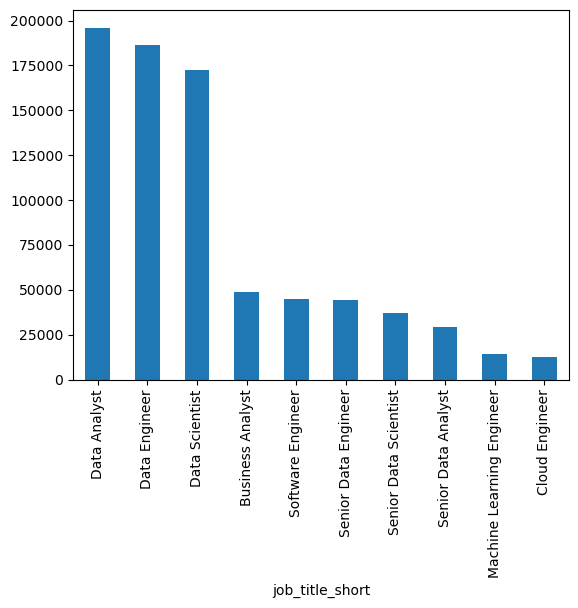

In [7]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar',ax=ax)

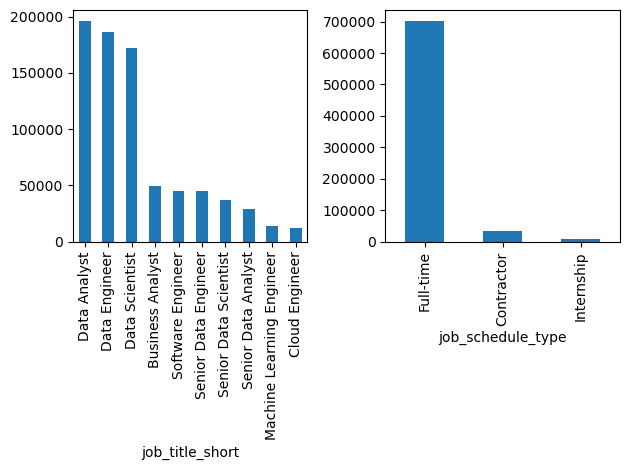

In [13]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar',ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[1])

fig.tight_layout()


In [ ]:
df['job_title_short'].value_counts()

df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

In [14]:
df_skills = df.copy()

df_skills = df_skills.explode('job_skills')

skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [24]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']

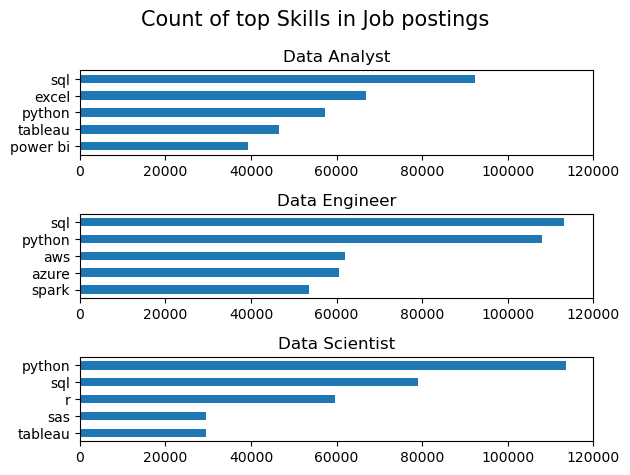

In [36]:
fig, ax=plt.subplots(3,1)

for i,job_title in enumerate(job_titles):
 df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
 df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title)
 ax[i].invert_yaxis()
 ax[i].set_ylabel('')
 ax[i].legend().set_visible(False)
 ax[i].set_xlim(0,120000)
 fig.suptitle('Count of top Skills in Job postings',fontsize = 15)
 fig.tight_layout()
